In [1]:
!pip install tensorflow opencv-python mediapipe scikit-learn matplotlib tensorflowjs
# Verify installations
import tensorflow as tf
import cv2 as cv2
import mediapipe as mp
from sklearn import datasets
import matplotlib.pyplot as plt
import time
import os
import numpy as np
print("All libraries imported successfully.")
# NOTE: always run this when freshly opening this/working on it

     ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
     ------ --------------------------------- 2.4/15.2 MB 11.8 MB/s eta 0:00:02
     ------------ --------------------------- 4.7/15.2 MB 11.8 MB/s eta 0:00:01
     ------------------- -------------------- 7.3/15.2 MB 11.8 MB/s eta 0:00:01
     ------------------------- -------------- 9.7/15.2 MB 11.8 MB/s eta 0:00:01
     ------------------------------- ------- 12.3/15.2 MB 11.8 MB/s eta 0:00:01
     ------------------------------------- - 14.7/15.2 MB 11.8 MB/s eta 0:00:01
     ---------------------------------------- 15.2/15.2 MB 11.5 MB/s  0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     -----------------------------------

  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [20 lines of output]
  Traceback (most recent call last):
    File "C:\Users\Dandar\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
      main()
      ~~~~^^
    File "C:\Users\Dandar\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
      json_out["return_val"] = hook(**hook_input["kwargs"])
                               ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\Dandar\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
      return hook(config_settings)
    File "C:\Users\Dandar\AppData\Local\Temp\pip-build-env-zty9_xcw\overlay\Lib\site-packages\setuptools\build_meta.py", line 333, in get_requires_for_build_wheel
      return self._get_build_requires(config_settings, req

ModuleNotFoundError: No module named 'tensorflow'

In [4]:
mp_holistic = mp.solutions.holistic # Holistic models
mp_drawing = mp.solutions.drawing_utils #drawing utils
print("holistics drawing is ready") # Confirms it

holistics drawing is ready


In [5]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #From BGR (Blue, Green, Red) to RGB
    image.flags.writeable = False #Restricts the image so it wouldnt be modified
    results = model.process(image) # Prediciton
    image.flags.writeable = True #Allows image to be modified
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) #From RGB to BGR (Blue, Green, Red)
    return image, results

In [6]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION) # this is face connections replaced by attribute "facemesh"
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # draws pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # draws left hand 
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)# draws right hand

In [7]:
def draw_styled_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION,
        mp_drawing.DrawingSpec(color=(80, 110, 10), thickness=1, circle_radius=1),  # the landmark aka circle color
        mp_drawing.DrawingSpec(color=(80, 0, 121), thickness=1, circle_radius=1)  # the connection aka line color
    )  # this is face connections replaced by attribute "facemesh"

    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(80, 22, 10), thickness=2, circle_radius=4),
        mp_drawing.DrawingSpec(color=(80, 44, 121), thickness=2, circle_radius=2)
    )  # draws pose connections

    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(121, 22, 76), thickness=2, circle_radius=4),
        mp_drawing.DrawingSpec(color=(121, 44, 250), thickness=2, circle_radius=2)
    )  # draws left hand 

    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(80, 110, 10), thickness=2, circle_radius=4),
        mp_drawing.DrawingSpec(color=(80, 0, 121), thickness=2, circle_radius=2)
    )  # draws right hand NOTE: FIX THIS ISSUE WITH COLOR CUSTOMISATION LATER!!!!!!!(fixed)


In [23]:
import cv2

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # draws landsmarks(key points)
        draw_styled_landmarks(image, results)
        
        # Show to screen
        cv2.imshow('Mizo Frame', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('x'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [25]:
results

mediapipe.python.solution_base.SolutionOutputs

In [27]:
draw_landmarks(frame, results)

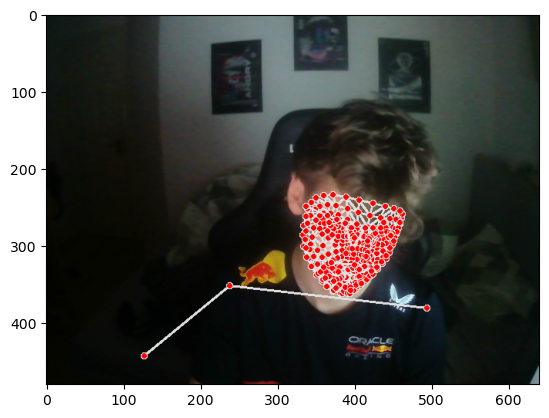

In [29]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))  # note this changes it from bgr to rgb cuz it looks funky :)

In [31]:
pose = [] 
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [33]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404) # error if statement in case the face is not in frame
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3) # error if statement in case the left hand is not in frame
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)# error if statement in case the right hand is not in frame

In [35]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404) # error if statement in case the face is not in frame
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3) # error if statement in case the left hand is not in frame
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)# error if statement in case the right hand is not in frame
    return np.concatenate([pose, face, lh, rh])# merges all the points together

In [37]:
# where all the data from 3. goes
DATA_PATH = os.path.join("MP_Data")
 
# actions to try to detect/recognise 
actions = np.array(["hello","thanks","yes","no"]) # NOTE: ADD more to make the ai more better and useful but need to update the shape for each action
# 30 videos worth of data NOTE: you can make it bigger for more accuracy
no_sequences = 150
# 30 frames per video NOTE: you can change it to 60 but would need to change the data shape from 30,1662 to 60,1662
sequence_length = 60

In [39]:
for action in actions:
    for sequence in range(no_sequences):
        try:
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except FileExistsError:
            pass

In [ ]:
import cv2
import numpy as np
import os
import mediapipe as mp
 
mp_holistic = mp.solutions.holistic
 
# --- UI Helper Functions ---
 
def draw_progress_bar(image, value, max_value, x, y, width=200, height=18, color=(0, 255, 120)):
    """Draws background, filled portion, and border of a progress bar."""
    cv2.rectangle(image, (x, y), (x + width, y + height), (50, 50, 50), -1)
    cv2.rectangle(image, (x, y), (x + int(width * value / max_value), y + height), color, -1)
    cv2.rectangle(image, (x, y), (x + width, y + height), (200, 200, 200), 1)
 
 
def draw_hud(image, action, sequence, no_sequences, frame_num, sequence_length, collecting=True):
    """Draws the heads-up display overlay during recording."""
    h, w = image.shape[:2]
 
    # Semi-transparent top banner
    overlay = image.copy()
    cv2.rectangle(overlay, (0, 0), (w, 70), (20, 20, 20), -1)
    cv2.addWeighted(overlay, 0.6, image, 0.4, 0, image)
 
    # Action label
    cv2.putText(image, f"ACTION: {action.upper()}", (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.85, (0, 255, 180), 2, cv2.LINE_AA)
 
    # Sequence count
    cv2.putText(image, f"Set {sequence + 1}/{no_sequences}", (15, 58),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (180, 180, 180), 1, cv2.LINE_AA)
 
    # Frame progress bar
    bx, by = w - 215, 10
    cv2.putText(image, "Frames", (bx, by + 12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (180, 180, 180), 1, cv2.LINE_AA)
    draw_progress_bar(image, frame_num + 1, sequence_length, bx, by + 18, color=(0, 200, 255))
    cv2.putText(image, f"{frame_num + 1}/{sequence_length}", (bx, by + 50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.42, (150, 150, 150), 1, cv2.LINE_AA)
 
    # Set progress bar
    sby = by + 60
    cv2.putText(image, "Sets", (bx, sby + 12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (180, 180, 180), 1, cv2.LINE_AA)
    draw_progress_bar(image, sequence + 1, no_sequences, bx, sby + 18, color=(0, 255, 120))
 
    # Recording indicator dot — red when active, grey when idle
    dot_color = (0, 0, 255) if collecting else (100, 100, 100)
    cv2.circle(image, (w - 20, 20), 8, dot_color, -1)
 
    # Quit hint
    cv2.putText(image, "Press 'x' to quit", (15, h - 12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (100, 100, 100), 1, cv2.LINE_AA)
 
 
def handle_pause(image):
    """Freezes on the current frame with a pause overlay.
    Returns False if the user quits, True if they resume."""
    h, w = image.shape[:2]
    paused_frame = image.copy()
 
    overlay = paused_frame.copy()
    cv2.rectangle(overlay, (0, 0), (w, h), (10, 10, 10), -1)
    cv2.addWeighted(overlay, 0.55, paused_frame, 0.45, 0, paused_frame)
 
    cv2.putText(paused_frame, "PAUSED", (w // 2 - 100, h // 2 - 20),
                cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 255, 180), 3, cv2.LINE_AA)
    cv2.putText(paused_frame, "Press 'p' to resume  |  'x' to quit",
                (w // 2 - 190, h // 2 + 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (180, 180, 180), 1, cv2.LINE_AA)
 
    while True:
        cv2.imshow('Mizo Frame', paused_frame)
        key = cv2.waitKey(50) & 0xFF
        if key == ord('p'):
            return True   # resume
        elif key == ord('x'):
            return False  # quit
 
 
def draw_countdown_screen(image, action, sequence, no_sequences, countdown_ms=3000):
    """Shows a countdown overlay before each set begins.
    Supports pausing (p) and quitting (x) during the countdown.
    Returns False if the user quits, True otherwise."""
    h, w = image.shape[:2]
 
    # Dark overlay on top of the live frame
    overlay = image.copy()
    cv2.rectangle(overlay, (0, 0), (w, h), (10, 10, 10), -1)
    cv2.addWeighted(overlay, 0.65, image, 0.35, 0, image)
 
    # GET READY label
    cv2.putText(image, "GET READY", (w // 2 - 130, h // 2 - 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.4, (0, 255, 180), 3, cv2.LINE_AA)
 
    # Action and set info
    cv2.putText(image, f"{action.upper()}  |  Set {sequence + 1} of {no_sequences}",
                (w // 2 - 160, h // 2 + 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 2, cv2.LINE_AA)
 
    # Key hint
    cv2.putText(image, "Press 'p' to pause  |  'x' to quit",
                (w // 2 - 170, h // 2 + 115),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (120, 120, 120), 1, cv2.LINE_AA)
 
    # While loop instead of for so we can restart the countdown cleanly after a pause
    steps = countdown_ms // 10
    i = 0
    while i < steps:
        temp = image.copy()
        elapsed = (i + 1) / steps
        bar_w = int((w - 100) * elapsed)
 
        # Filled bar and border
        cv2.rectangle(temp, (50, h // 2 + 40), (50 + bar_w, h // 2 + 65), (0, 255, 180), -1)
        cv2.rectangle(temp, (50, h // 2 + 40), (w - 50, h // 2 + 65), (200, 200, 200), 2)
 
        # Seconds remaining label
        secs_left = round((countdown_ms - (i + 1) * 10) / 1000, 1)
        cv2.putText(temp, f"Starting in {secs_left}s", (w // 2 - 90, h // 2 + 100),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (180, 180, 180), 1, cv2.LINE_AA)
 
        cv2.imshow('Mizo Frame', temp)
        key = cv2.waitKey(10) & 0xFF
 
        if key == ord('x'):
            return False
        elif key == ord('p'):
            resumed = handle_pause(temp)
            if not resumed:
                return False
            i = 0        # restart the countdown so user gets the full window to get ready
            continue
 
        i += 1
 
    return True
 
 
# --- Main Collection Loop ---
 
cap = cv2.VideoCapture(0)
 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
 
    abort = False  # single flag to break all loops cleanly
 
    for action in actions:
        if abort:
            break
 
        for sequence in range(no_sequences):
            if abort:
                break
 
            for frame_num in range(sequence_length):
 
                ret, frame = cap.read()
                if not ret:
                    print("Camera error, stopping collection.")
                    abort = True
                    break
 
                image, results = mediapipe_detection(frame, holistic)
                draw_styled_landmarks(image, results)
 
                if frame_num == 0:
                    should_continue = draw_countdown_screen(image, action, sequence, no_sequences)
                    if not should_continue:
                        abort = True
                        break
 
                    # Fresh frame after countdown
                    ret, frame = cap.read()
                    if not ret:
                        abort = True
                        break
                    image, results = mediapipe_detection(frame, holistic)
                    draw_styled_landmarks(image, results)
 
                draw_hud(image, action, sequence, no_sequences, frame_num, sequence_length)
                cv2.imshow('Mizo Frame', image)
 
                key = cv2.waitKey(10) & 0xFF
                if key == ord("x"):
                    abort = True   # propagate quit to all outer loops
                    break
 
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)
 
cap.release()
cv2.destroyAllWindows()
 

In [45]:
label_map = {action: num for num, action in enumerate(actions)}

sequences, label = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action , str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        label.append(label_map[action])

In [46]:
X= np.array(sequences)

In [47]:
from sklearn.preprocessing import StandardScaler
import pickle

nsamples, nframes, nfeatures = X.shape #shapes into (240,60,1662)
X_reshaped = X.reshape(-1, nfeatures) # flattens to (10800, 1662) so scaler works on features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)  # learns mean/std from training data
X = X_scaled.reshape(nsamples, nframes, nfeatures)  # reshape back to (240,60,1662)

# Save the scaler — you MUST use this same scaler at inference time
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(f"Data shape: {X.shape}")
print("Scaler saved.")

Data shape: (600, 60, 1662)
Scaler saved.


In [48]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(label).astype(int)

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        # ensures each action is evenly represented in both sets
    random_state=42
)
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Training samples: 480, Test samples: 120


In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
print("LSTM imported")

LSTM imported


In [51]:
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
import datetime

run_name = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")#formatted as Year,Month,Day,Hour,Minute,Second
# Defines the path for the "Logs" folder and the metadata associated
log_dir = os.path.join("Logs", run_name)

# Ensure that the "Logs" folder exists
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

# Initialize the TensorBoard callback with the log directory
tb_callback = TensorBoard(log_dir=log_dir,histogram_freq=1,write_graph=True,update_freq="epoch")
# tb_callback has been updated to show weight and bias distribution per epoch session,visualising model graph and logs frequency per epoch
# You can now use tb_callback in model training

early_stop = EarlyStopping(monitor="val_loss",patience=75,restore_best_weights=True)
# watches validation loss and stops if no improvement for 50 epoch and saves the weights based on the highest epoch accuracy

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.8,    # was 0.5 — smaller steps
    patience=20,
    min_lr=1e-5
)
# halves the learning rate when val_loss stops improving, instead of stopping outright
print(f"Logging to: {log_dir}")

Logging to: Logs\20260319-215049


In [52]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.constraints import MaxNorm
from tensorflow.keras.initializers import GlorotUniform, Zeros 

model = Sequential()
model.add(Input(shape=(60, 1662)))
model.add(LSTM(64, return_sequences=True, activation="tanh",
               kernel_regularizer=l2(0.01),
               bias_regularizer=l2(0.05)))
model.add(LayerNormalization()) 
model.add(Dropout(0.4))

model.add(LSTM(64, return_sequences=False, activation="tanh",
               kernel_regularizer=l2(0.01),
               bias_regularizer=l2(0.05)))
model.add(LayerNormalization()) 
model.add(Dropout(0.4))

model.add(Dense(32, activation="relu",
                kernel_regularizer=l2(0.01),
                bias_regularizer=l2(0.05),
                kernel_initializer=GlorotUniform(),
                bias_initializer=Zeros()))
model.add(LayerNormalization()) 
model.add(Dropout(0.4))

model.add(Dense(actions.shape[0], activation="softmax",
                bias_regularizer=l2(0.05),
                bias_initializer=Zeros()))


In [53]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=AdamW(learning_rate=0.0005, weight_decay=1e-4),  # was default 0.001 — slower = more controlled bias updates
    loss="categorical_crossentropy",
    metrics=["categorical_accuracy"]
)  #metrics is the variable that concludes the model accureate to what it is displaying

In [54]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │         442,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization                  │ (None, 60, 64)              │             128 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization_1                │ (None, 64)                  │             128 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization_2                │ (None, 32)                  │              64 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 477,668 (1.82 MB)

 Trainable params: 477,668 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.fit(
    X_train, y_train,
    epochs=2000,
    shuffle=True,
    validation_data=(X_test, y_test),
    callbacks=[tb_callback, early_stop, reduce_lr]
)
# NOTE: use tensorboard web to see data through cmd "tensorboard --logdir=Logs"
# validation curves in Tensorboard for histogram and graphs

Epoch 1/2000
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - categorical_accuracy: 0.3519 - loss: 14.2846 - val_categorical_accuracy: 0.6917 - val_loss: 12.9974 - learning_rate: 5.0000e-04
Epoch 2/2000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - categorical_accuracy: 0.5580 - loss: 13.2029 - val_categorical_accuracy: 0.7333 - val_loss: 12.5477 - learning_rate: 5.0000e-04
Epoch 3/2000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - categorical_accuracy: 0.6143 - loss: 12.7843 - val_categorical_accuracy: 0.7750 - val_loss: 12.2423 - learning_rate: 5.0000e-04
Epoch 4/2000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - categorical_accuracy: 0.6953 - loss: 12.3827 - val_categorical_accuracy: 0.8167 - val_loss: 11.9905 - learning_rate: 5.0000e-04
Epoch 5/2000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - categorical_accuracy: 0.6839 - loss: 12.0956 - val_categorical_accuracy: 0.8500 - val_loss: 11.6306 - learning_rate: 5.0000e-04
Epoch 6/2000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - categorical_accuracy: 0.7619 -

8.Making Predictions

In [57]:
%load_ext tensorboard
%tensorboard --logdir=Logs

Reusing TensorBoard on port 6006 (pid 28128), started 2:51:43 ago. (Use '!kill 28128' to kill it.)

In [ ]:
actions[np.argmax(res[0])]

In [ ]:
actions[np.argmax(y_test[0])]

9.Saving the Data(Weights)

In [ ]:
model.save("Mizo.h5") # Save the TF Model

In [ ]:
del model #NOTE: USE IT IF MODEL IS UNSTABLE AND/OR UNUSABLE // AS A LAST RESORT, REBUILD THE MODEL

In [ ]:
model.load_weights("Mizo.h5") # ONLY Recovers the weight file if user accidently deletes it

In [ ]:
from tensorflow.keras.models import load_model

model= load_model("Mizo.h5") #Recovers the model file if the user accidently deletes it

10.Evaluation using Confusion Matrix and Accuracy

In [70]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [72]:
yhat = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


In [74]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [76]:
multilabel_confusion_matrix(ytrue, yhat) #NOTE refer to the confusion matrix with false negatives and true positives

array([[[89,  1],
        [ 1, 29]],

       [[88,  2],
        [ 3, 27]],

       [[89,  1],
        [ 0, 30]],

       [[88,  2],
        [ 2, 28]]], dtype=int64)

In [78]:
accuracy_score(ytrue, yhat)

0.95

11. TESTING IN REAL TIME 

In [80]:
colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)

    return output_frame

In [88]:
# New detections
import pickle
import colorsys
import numpy as np
from collections import Counter

# Load the scaler used during training to normalise keypoints the same way
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Must match the same actions used during training
actions = np.array(["hello", "thanks", "yes", "no"])

def generate_colors(n):
    """Generates n visually distinct BGR colors."""
    colors = []
    for i in range(n):
        hue = i / n
        r, g, b = colorsys.hsv_to_rgb(hue, 0.85, 0.95)
        colors.append((int(b * 255), int(g * 255), int(r * 255)))  # BGR for OpenCV
    return colors

colors = generate_colors(len(actions))  # automatically scales to however many actions you have

# Per-class thresholds — temporarily very relaxed to diagnose detection issues
thresholds = {
    "hello":  0.02,   # relaxed for debugging
    "thanks": 0.70,   # relaxed for debugging
    "yes":    0.80,   # relaxed for debugging
    "no":     0.25    # relaxed for debugging
}

sequence = []    # collects the 60 frames for more recognisable and smoother input
sentence = []    # stores the last 5 predicted actions to display on screen
predictions = [] # predicts the action during transition

cap = cv2.VideoCapture(0)

# Set mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        # Make detections
        image, results = mediapipe_detection(frame, holistic)

        # SOFTENED landmark check — only skips if absolutely no landmarks detected at all
        # Removed strict pose_landmarks check as fast hand gestures (hello/thanks) can
        # temporarily lose pose_landmarks mid-gesture, breaking the 60-frame window
        if not results.left_hand_landmarks and not results.right_hand_landmarks and not results.pose_landmarks:
            print("No landmarks detected at all — skipping frame")
            continue

        # Draw landmarks (key points)
        draw_styled_landmarks(image, results)

        # Prediction logic
        keypoints_raw = extract_keypoints(results)

        # DEBUG — check if scaler is distorting live keypoints vs training data
        # If scaled values are way outside -3 to 3, the scaler is the problem
        keypoints_scaled = scaler.transform(keypoints_raw.reshape(1, -1)).flatten()
        print(f"Raw      — min: {keypoints_raw.min():.3f}, max: {keypoints_raw.max():.3f}, mean: {keypoints_raw.mean():.3f}")
        print(f"Scaled   — min: {keypoints_scaled.min():.3f}, max: {keypoints_scaled.max():.3f}, mean: {keypoints_scaled.mean():.3f}")

        sequence.append(keypoints_scaled)
        sequence = sequence[-60:]  # keep only the last 60 frames, drops older frames as new ones come in

        if len(sequence) == 60:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]

            # DEBUG — print full prediction breakdown for every action every frame
            print("\n--- Prediction Breakdown ---")
            for i, action in enumerate(actions):
                print(f"  {action}: {res[i]:.4f}")
            print(f"  Top prediction : {actions[np.argmax(res)]} | Confidence: {res[np.argmax(res)]:.4f}")

            predictions.append(np.argmax(res))          # actually makes the logic executable
            predictions = predictions[-10:]             # prevents it from exponentially growing and adds a cap

            predicted_action = actions[np.argmax(res)]  # gets the action name from the highest predicted index
            confidence = res[np.argmax(res)]            # confidence score for the predicted action

            # DEBUG — print vote distribution so we can see if votes are accumulating
            if len(predictions) == 10:
                most_common, count = Counter(predictions).most_common(1)[0]
                vote_confidence = count / 10
                print(f"  Votes          : {dict(Counter(predictions))}")
                print(f"  Vote confidence: {vote_confidence:.1f} (need 0.5)")
                print(f"  Threshold      : {thresholds[predicted_action]} (need < {confidence:.4f})")
                print("----------------------------\n")

                # Relaxed to 0.5 vote confidence for debugging — tighten once working
                if vote_confidence >= 0.5 and confidence > thresholds[predicted_action]:
                    predicted_action = actions[most_common]
                    if len(sentence) == 0 or predicted_action != sentence[-1]:  # avoid repeating the same word consecutively
                        sentence.append(predicted_action)

            sentence = sentence[-5:]  # keep only the last 5 predictions to avoid cluttering the screen
            print(f"Current sentence: {sentence}")

            # Draw probability bars for each action on screen
            image = prob_viz(res, actions, image, colors)

            # Draw the sentence banner at the top of the frame
            cv2.rectangle(image, (0, 0), (640, 40), (245, 117, 16), -1)
            cv2.putText(image, " ".join(sentence), (3, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)  # determines the box on the top left

        # Show to screen
        cv2.imshow('Mizo Frame', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('x'):
            break

cap.release()
cv2.destroyAllWindows()

No landmarks detected at all — skipping frame
No landmarks detected at all — skipping frame
No landmarks detected at all — skipping frame
Raw      — min: -0.800, max: 2.207, mean: 0.351
Scaled   — min: -3.216, max: 4.302, mean: 0.968
Raw      — min: -0.821, max: 2.269, mean: 0.351
Scaled   — min: -2.997, max: 4.296, mean: 0.964
Raw      — min: -0.953, max: 2.262, mean: 0.350
Scaled   — min: -2.905, max: 4.361, mean: 0.949
Raw      — min: -1.096, max: 2.254, mean: 0.349
Scaled   — min: -2.805, max: 4.304, mean: 0.941
Raw      — min: -1.001, max: 2.254, mean: 0.349
Scaled   — min: -2.711, max: 4.117, mean: 0.948
Raw      — min: -1.233, max: 2.251, mean: 0.347
Scaled   — min: -3.353, max: 4.101, mean: 0.951
Raw      — min: -1.163, max: 2.252, mean: 0.347
Scaled   — min: -2.872, max: 4.060, mean: 0.927
Raw      — min: -1.347, max: 2.260, mean: 0.346
Scaled   — min: -4.685, max: 4.063, mean: 0.916
Raw      — min: -1.188, max: 2.324, mean: 0.347
Scaled   — min: -4.817, max: 4.252, mean: 0.92

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=actions))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", 
            xticklabels=actions, 
            yticklabels=actions,
            cmap="Blues")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
TFJS

In [ ]:
import subprocess

result = subprocess.run([
    "tensorflowjs_converter",
    "--input_format=keras",
    "Mizo.h5",
    "Mizo_tfjs/"          # output folder
], capture_output=True, text=True)

print(result.stdout)
print(result.stderr)

In [ ]:
TFLITE

In [2]:
import tensorflow as tf

# Load your saved model
model = tf.keras.models.load_model("Mizo.h5")

# Create the TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optional: apply optimizations (reduces size, speeds up on mobile)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert
tflite_model = converter.convert()

# Save to disk
with open("Mizo.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved as Mizo.tflite")
print(f"File size: {len(tflite_model) / 1024:.1f} KB")

ModuleNotFoundError: No module named 'tensorflow'